# Price Analysis

This notebook loads price data from the repo `data/` folder, combines the available days, and starts by calculating rolling volatility from the mid-price series.

Change `DATA_GLOB` if you want to narrow the input files.


In [1]:
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

DATA_GLOB = "../../data/prices_round_*.csv"
PRODUCT = "ASH_COATED_OSMIUM"
ROLLING_WINDOW = 80



In [2]:
price_paths = sorted(Path().glob(DATA_GLOB))
raw_prices = pd.concat((pd.read_csv(path, sep=";") for path in price_paths), ignore_index=True)

prices = (
    raw_prices.loc[raw_prices["product"] == PRODUCT]
    .copy()
    .sort_values(["day", "timestamp"])
    .reset_index(drop=True)
)

# Recalculate mid_price as average of bid and ask when both available
prices["mid_price"] = prices.apply(
    lambda row: (row["bid_price_1"] + row["ask_price_1"]) / 2 
    if pd.notna(row["bid_price_1"]) and pd.notna(row["ask_price_1"]) 
    else np.nan, 
    axis=1
)

# Fill NaN mid_price with forward fill, then backward fill to avoid gaps in the series
prices["mid_price"] = prices["mid_price"].ffill().bfill()

prices["two_sided_quote"] = prices["bid_price_1"].notna() & prices["ask_price_1"].notna()
prices["spread"] = np.where(prices["two_sided_quote"], prices["ask_price_1"] - prices["bid_price_1"], np.nan)
prices["spread_bps"] = np.where(
    prices["two_sided_quote"] & prices["mid_price"].gt(0),
    (prices["spread"] / prices["mid_price"]) * 10_000,
    np.nan,
)

top_bid_size = prices["bid_volume_1"] if "bid_volume_1" in prices.columns else pd.Series(np.nan, index=prices.index)
top_ask_size = prices["ask_volume_1"].abs() if "ask_volume_1" in prices.columns else pd.Series(np.nan, index=prices.index)
prices["top_bid_size"] = top_bid_size
prices["top_ask_size"] = top_ask_size
prices["top_depth"] = prices["top_bid_size"] + prices["top_ask_size"]

bid_volume_cols = [col for col in prices.columns if col.startswith("bid_volume_")]
ask_volume_cols = [col for col in prices.columns if col.startswith("ask_volume_")]
prices["total_bid_volume"] = prices[bid_volume_cols].fillna(0).sum(axis=1) if bid_volume_cols else np.nan
prices["total_ask_volume"] = prices[ask_volume_cols].abs().fillna(0).sum(axis=1) if ask_volume_cols else np.nan
prices["total_visible_volume"] = prices["total_bid_volume"] + prices["total_ask_volume"]
prices["imbalance"] = np.where(
    prices["top_depth"] > 0,
    (prices["top_bid_size"] - prices["top_ask_size"]) / prices["top_depth"],
    np.nan,
)
prices["abs_mid_change"] = prices.groupby("day")["mid_price"].diff().abs()

prices["event_index"] = range(len(prices))
price_paths, prices[["day", "timestamp", "product", "bid_price_1", "ask_price_1", "mid_price"]].head()

([PosixPath('data/prices_round_1_day_-1.csv'),
  PosixPath('data/prices_round_1_day_-2.csv'),
  PosixPath('data/prices_round_1_day_0.csv')],
    day  timestamp            product  bid_price_1  ask_price_1  mid_price
 0   -2          0  ASH_COATED_OSMIUM          NaN      10010.0    10000.0
 1   -2        100  ASH_COATED_OSMIUM       9992.0      10008.0    10000.0
 2   -2        200  ASH_COATED_OSMIUM       9992.0      10008.0    10000.0
 3   -2        300  ASH_COATED_OSMIUM       9992.0      10008.0    10000.0
 4   -2        400  ASH_COATED_OSMIUM       9992.0      10008.0    10000.0)

## Rolling Volatility

A common choice is to compute volatility on returns rather than on raw prices. Here we use percentage returns of the `mid_price`, then take a rolling standard deviation over the last `ROLLING_WINDOW` observations.


In [3]:
prices["mid_return"] = prices["mid_price"].pct_change()
prices[f"rolling_volatility_{ROLLING_WINDOW}"] = (
    prices["mid_return"].rolling(ROLLING_WINDOW).std() * (ROLLING_WINDOW ** 0.5)
)

prices[[
    "day",
    "timestamp",
    "mid_price",
    "mid_return",
    f"rolling_volatility_{ROLLING_WINDOW}",
]].tail(25)


,day,timestamp,mid_price,mid_return,rolling_volatility_80
29975,0,997500,10008.0,0.00000,0.002312
29976,0,997600,10007.0,-0.00010,0.002315
29977,0,997700,10008.0,0.00010,0.002317
29978,0,997800,10004.5,-0.00035,0.002343
29979,0,997900,10008.0,0.00035,0.002365
29980,0,998000,10009.0,0.00010,0.002362
29981,0,998100,10008.5,-0.00005,0.002360
29982,0,998200,10007.0,-0.00015,0.002346
29983,0,998300,10007.0,0.00000,0.002344
29984,0,998400,10008.5,0.00015,0.002329


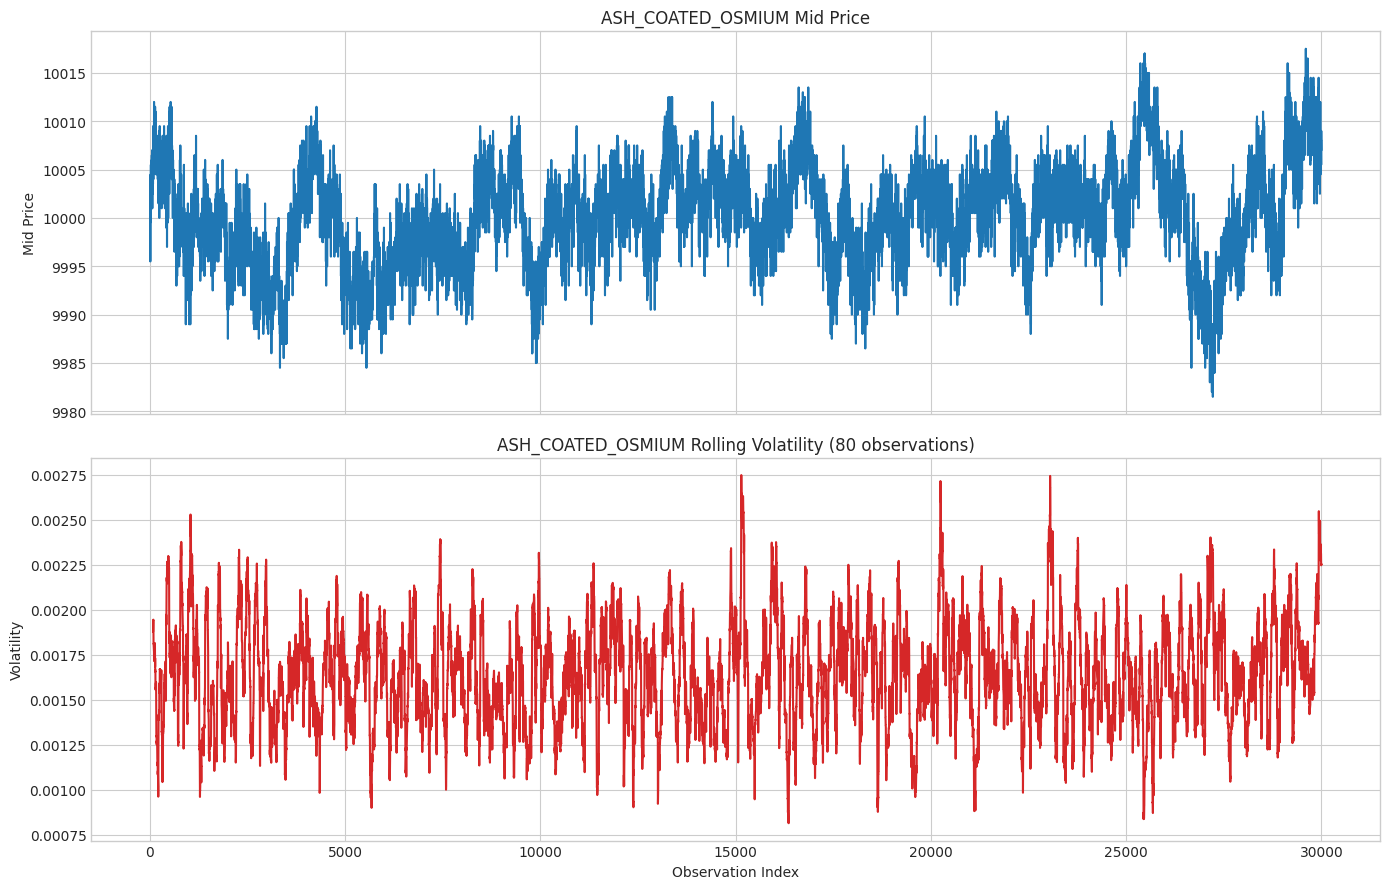

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(prices["event_index"], prices["mid_price"], color="tab:blue", linewidth=1.5)
axes[0].set_title(f"{PRODUCT} Mid Price")
axes[0].set_ylabel("Mid Price")

axes[1].plot(
    prices["event_index"],
    prices[f"rolling_volatility_{ROLLING_WINDOW}"],
    color="tab:red",
    linewidth=1.5,
)
axes[1].set_title(f"{PRODUCT} Rolling Volatility ({ROLLING_WINDOW} observations)")
axes[1].set_xlabel("Observation Index")
axes[1].set_ylabel("Volatility")

plt.tight_layout()
plt.show()


## Market Quality Metrics

This section summarizes execution-relevant microstructure statistics for `PRODUCT`, including average spread, spread in basis points, visible volume, top-of-book depth, and queue imbalance.


In [ ]:
market_quality_summary = pd.Series({
    "observations": len(prices),
    "two_sided_quote_share_pct": prices["two_sided_quote"].mean() * 100,
    "average_mid_price": prices["mid_price"].mean(),
    "mid_price_range": prices["mid_price"].max() - prices["mid_price"].min(),
    "average_spread": prices["spread"].mean(),
    "median_spread": prices["spread"].median(),
    "spread_p95": prices["spread"].quantile(0.95),
    "average_spread_bps": prices["spread_bps"].mean(),
    "average_abs_mid_change": prices["abs_mid_change"].mean(),
    "average_total_bid_volume": prices["total_bid_volume"].mean(),
    "average_total_ask_volume": prices["total_ask_volume"].mean(),
    "average_total_visible_volume": prices["total_visible_volume"].mean(),
    "visible_volume_p95": prices["total_visible_volume"].quantile(0.95),
    "average_top_depth": prices["top_depth"].mean(),
    "average_abs_imbalance": prices["imbalance"].abs().mean(),
})

market_quality_by_day = (
    prices.groupby("day")
    .agg(
        observations=("event_index", "count"),
        two_sided_quote_share_pct=("two_sided_quote", lambda s: s.mean() * 100),
        average_mid_price=("mid_price", "mean"),
        average_spread=("spread", "mean"),
        median_spread=("spread", "median"),
        spread_p95=("spread", lambda s: s.quantile(0.95)),
        average_spread_bps=("spread_bps", "mean"),
        average_abs_mid_change=("abs_mid_change", "mean"),
        average_total_bid_volume=("total_bid_volume", "mean"),
        average_total_ask_volume=("total_ask_volume", "mean"),
        average_total_visible_volume=("total_visible_volume", "mean"),
        visible_volume_p95=("total_visible_volume", lambda s: s.quantile(0.95)),
        average_top_depth=("top_depth", "mean"),
        average_abs_imbalance=("imbalance", lambda s: s.abs().mean()),
        realized_vol_bps=("mid_return", lambda s: s.dropna().std() * np.sqrt(s.dropna().size) * 10_000 if s.dropna().size > 1 else np.nan),
    )
    .round(4)
)

market_quality_summary = market_quality_summary.round(4).to_frame("value")
display(market_quality_summary)
market_quality_by_day


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

rolling_spread = prices["spread"].rolling(ROLLING_WINDOW, min_periods=1).mean()
rolling_visible_volume = prices["total_visible_volume"].rolling(ROLLING_WINDOW, min_periods=1).mean()

axes[0].plot(prices["event_index"], prices["spread"], color="tab:purple", linewidth=1, alpha=0.55, label="Spread")
axes[0].plot(
    prices["event_index"],
    rolling_spread,
    color="tab:red",
    linewidth=1.5,
    label=f"Rolling mean spread ({ROLLING_WINDOW})",
)
axes[0].set_title(f"{PRODUCT} Spread and Rolling Average")
axes[0].set_ylabel("Spread")
axes[0].legend()

axes[1].plot(prices["event_index"], prices["imbalance"], color="tab:green", linewidth=1)
axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_title(f"{PRODUCT} Top-of-Book Imbalance")
axes[1].set_ylabel("Imbalance")

axes[2].plot(
    prices["event_index"],
    prices["total_visible_volume"],
    color="tab:blue",
    linewidth=1,
    alpha=0.5,
    label="Visible volume",
)
axes[2].plot(
    prices["event_index"],
    rolling_visible_volume,
    color="tab:orange",
    linewidth=1.5,
    label=f"Rolling mean visible volume ({ROLLING_WINDOW})",
)
axes[2].set_title(f"{PRODUCT} Visible Volume")
axes[2].set_xlabel("Observation Index")
axes[2].set_ylabel("Volume")
axes[2].legend()

plt.tight_layout()
plt.show()


## Trend Persistence From Log Returns

To test whether `PRODUCT` trends tick to tick, compute log returns within each day, take the sign of each return, and compare it to the previous tick's sign. If the same-sign percentage is materially above `50%`, that suggests short-horizon persistence. Below `50%` suggests the series is more choppy or mean-reverting than trending.


In [5]:
prices["log_return"] = prices.groupby("day")["mid_price"].transform(lambda s: np.log(s).diff())
prices["log_return_sign"] = np.sign(prices["log_return"])
prices["prev_log_return_sign"] = prices.groupby("day")["log_return_sign"].shift(1)

same_sign_mask = (
    prices["log_return_sign"].notna()
    & prices["prev_log_return_sign"].notna()
    & prices["log_return_sign"].ne(0)
    & prices["prev_log_return_sign"].ne(0)
)

trend_summary = pd.DataFrame(
    {
        "same_sign_pct": [
            (prices.loc[same_sign_mask, "log_return_sign"] == prices.loc[same_sign_mask, "prev_log_return_sign"]).mean() * 100
        ],
        "opposite_sign_pct": [
            (prices.loc[same_sign_mask, "log_return_sign"] != prices.loc[same_sign_mask, "prev_log_return_sign"]).mean() * 100
        ],
        "zero_involved_pct": [
            ((prices["log_return_sign"].eq(0) | prices["prev_log_return_sign"].eq(0)).fillna(False)).mean() * 100
        ],
        "observations_used": [int(same_sign_mask.sum())],
    },
    index=["overall"],
).round(2)

trend_by_day = (
    prices.loc[same_sign_mask, ["day", "log_return_sign", "prev_log_return_sign"]]
    .assign(same_sign=lambda df: df["log_return_sign"] == df["prev_log_return_sign"])
    .groupby("day")["same_sign"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "same_sign_pct", "count": "observations_used"})
)
trend_by_day["same_sign_pct"] = (trend_by_day["same_sign_pct"] * 100).round(2)

print(
    "TOMATOES shows short-horizon trend persistence."
    if trend_summary.loc["overall", "same_sign_pct"] > 50
    else "TOMATOES does not show short-horizon trend persistence; sign flips are more common than same-direction moves."
)

trend_summary, trend_by_day


TOMATOES does not show short-horizon trend persistence; sign flips are more common than same-direction moves.


(         same_sign_pct  opposite_sign_pct  zero_involved_pct  observations_used
 overall          23.93              76.07              57.28              12812,
      same_sign_pct  observations_used
 day                                  
 -2           23.04               4244
 -1           24.66               4274
  0           24.08               4294)

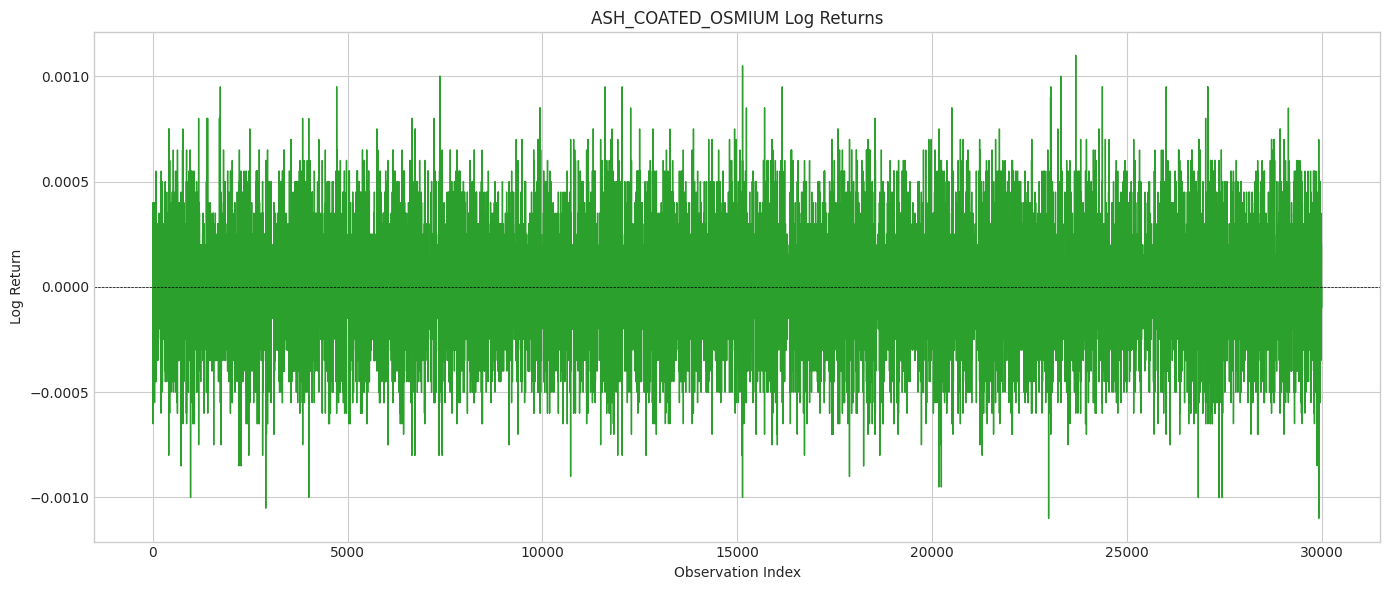

In [6]:
trend_summary, trend_by_day
# Plot log returns
plt.figure(figsize=(14, 6))
plt.plot(prices["event_index"], prices["log_return"], color="tab:green", linewidth=1)
plt.title(f"{PRODUCT} Log Returns")
plt.xlabel("Observation Index")
plt.ylabel("Log Return")
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

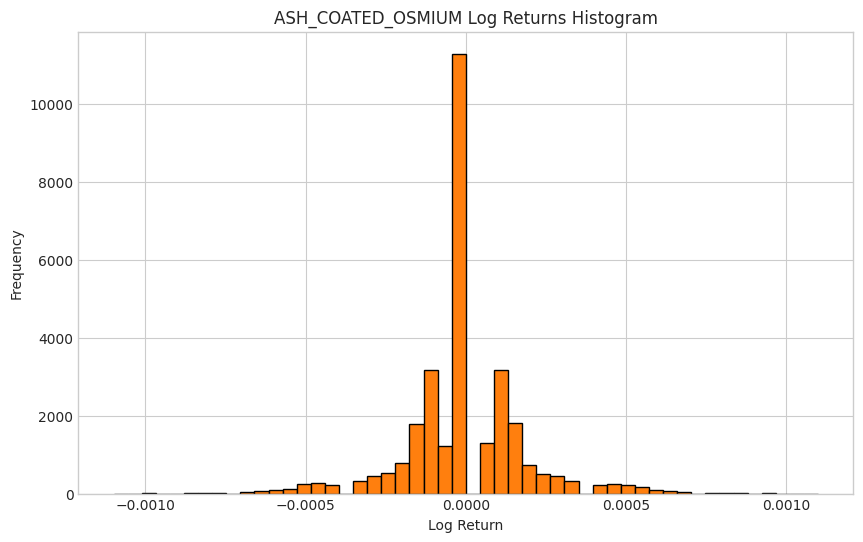

Log Returns Stats:
Positive: 9375 (31.25%)
Negative: 9327 (31.09%)
Zero: 11295 (37.65%)
Total observations: 29997


In [7]:
# Histogram of log returns
plt.figure(figsize=(10, 6))
plt.hist(prices["log_return"].dropna(), bins=50, color="tab:orange", edgecolor="black")
plt.title(f"{PRODUCT} Log Returns Histogram")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.show()


# Stats on log returns signs
log_returns_clean = prices["log_return"].dropna()
positive = (log_returns_clean > 0).sum()
negative = (log_returns_clean < 0).sum()
zero = (log_returns_clean == 0).sum()
total = len(log_returns_clean)

print(f"Log Returns Stats:")
print(f"Positive: {positive} ({positive/total*100:.2f}%)")
print(f"Negative: {negative} ({negative/total*100:.2f}%)")
print(f"Zero: {zero} ({zero/total*100:.2f}%)")
print(f"Total observations: {total}")

In [16]:
# Compute transition probabilities and expected returns by log-return sign transition
transition_data = prices.loc[
    prices['prev_log_return_sign'].notna() & prices['log_return_sign'].notna(),
    ['prev_log_return_sign', 'log_return_sign', 'log_return']
].copy()

transition_data['prev_log_return_sign'] = transition_data['prev_log_return_sign'].astype(int)
transition_data['log_return_sign'] = transition_data['log_return_sign'].astype(int)

transition_counts = (
    transition_data.groupby(['prev_log_return_sign', 'log_return_sign'])
    .agg(count=('log_return', 'size'), mean_return=('log_return', 'mean'))
)

transition_probs = (
    transition_counts['count']
    .unstack(fill_value=0)
    .reindex(index=[-1, 0, 1], columns=[-1, 0, 1], fill_value=0)
)
transition_probs = transition_probs.div(transition_probs.sum(axis=1), axis=0) * 100

expected_returns = (
    transition_counts['mean_return']
    .unstack(fill_value=np.nan)
    .reindex(index=[-1, 0, 1], columns=[-1, 0, 1])
)


In [9]:
# Specific requested probabilities
print("\nSpecific Transitions:")
print(f"P(Positive after Negative): {transition_probs.loc[-1, 1]:.2f}%")
print(f"P(Negative after Positive): {transition_probs.loc[1, -1]:.2f}%")
print(f"P(Positive after Zero): {transition_probs.loc[0, 1]:.2f}%")
print(f"P(Zero after Zero): {transition_probs.loc[0, 0]:.2f}%")
print(f"P(Negative after Zero): {transition_probs.loc[0, -1]:.2f}%")
print(f"P(Negative after Negative): {transition_probs.loc[-1, -1]:.2f}%")
print(f"P(Positive after Positive): {transition_probs.loc[1, 1]:.2f}%")


Specific Transitions:
P(Positive after Negative): 52.42%
P(Negative after Positive): 51.81%
P(Positive after Zero): 26.08%
P(Zero after Zero): 47.87%
P(Negative after Zero): 26.05%
P(Negative after Negative): 16.37%
P(Positive after Positive): 16.42%


In [17]:
# Specific expected values
print("\nSpecific Expected Returns:")
print(f"E[Return | Positive after Negative]: {expected_returns.loc[-1, 1]:.6f}")
print(f"E[Return | Negative after Positive]: {expected_returns.loc[1, -1]:.6f}")
print(f"E[Return | Positive after Zero]: {expected_returns.loc[0, 1]:.6f}")
print(f"E[Return | Zero after Zero]: {expected_returns.loc[0, 0]:.6f}")
print(f"E[Return | Negative after Zero]: {expected_returns.loc[0, -1]:.6f}")
print(f"E[Return | Negative after Negative]: {expected_returns.loc[-1, -1]:.6f}")
print(f"E[Return | Positive after Positive]: {expected_returns.loc[1, 1]:.6f}")


# Expected value from buying at first tick and holding entire series
total_log_return = prices["log_return"].sum()
total_return_pct = (np.exp(total_log_return) - 1) * 100
avg_log_return_per_tick = prices["log_return"].mean()
num_ticks = len(prices["log_return"].dropna())

print("Buy and Hold Strategy:")
print(f"Total log return: {total_log_return:.6f}")
print(f"Total return: {total_return_pct:.2f}%")
print(f"Average log return per tick: {avg_log_return_per_tick:.6f}")
print(f"Number of ticks: {num_ticks}")
print(f"Expected value per tick (average log return): {avg_log_return_per_tick:.6f}")


Specific Expected Returns:
E[Return | Positive after Negative]: 0.000209
E[Return | Negative after Positive]: -0.000208
E[Return | Positive after Zero]: 0.000162
E[Return | Zero after Zero]: 0.000000
E[Return | Negative after Zero]: -0.000164
E[Return | Negative after Negative]: -0.000158
E[Return | Positive after Positive]: 0.000153
Buy and Hold Strategy:
Total log return: 0.000700
Total return: 0.07%
Average log return per tick: 0.000000
Number of ticks: 29997
Expected value per tick (average log return): 0.000000


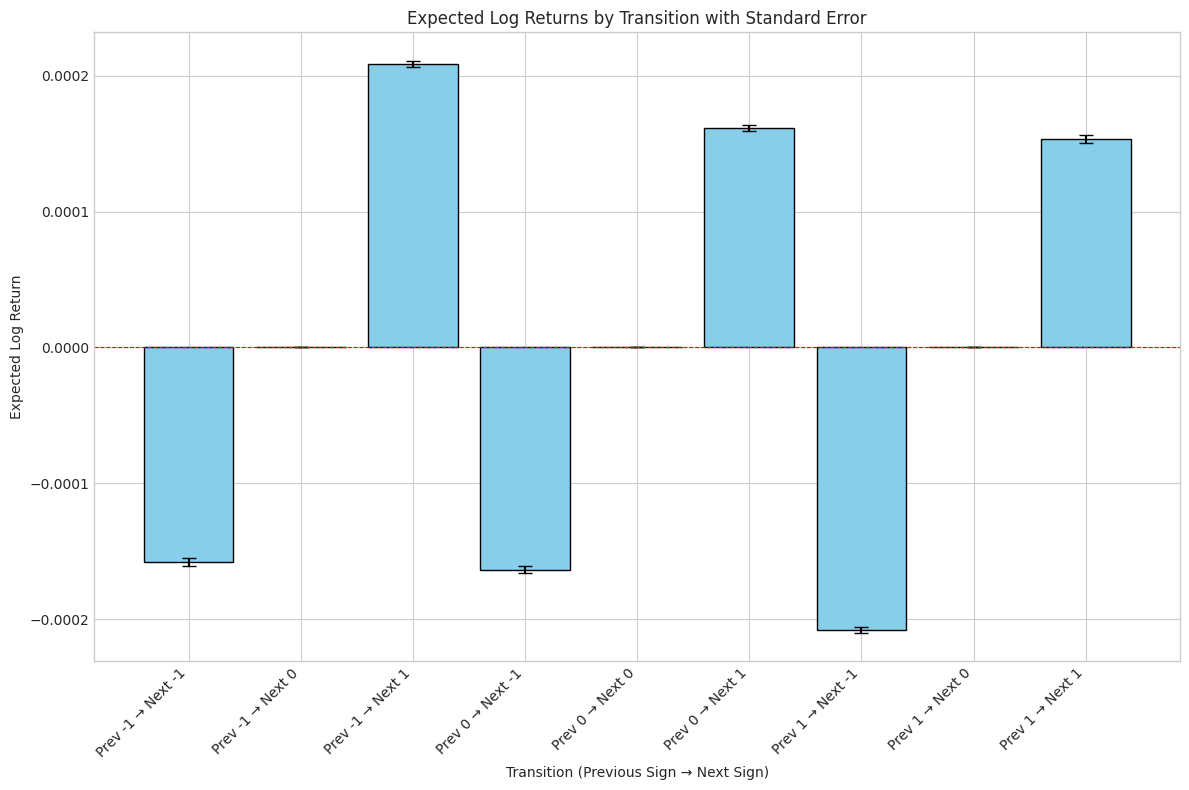

In [18]:
# Compute standard errors for each transition (std / sqrt(n))
se_returns = pd.DataFrame(index=[-1, 0, 1], columns=[-1, 0, 1])
counts = pd.DataFrame(index=[-1, 0, 1], columns=[-1, 0, 1])
for prev in [-1, 0, 1]:
    for next_ in [-1, 0, 1]:
        mask = (prices["prev_log_return_sign"] == prev) & (prices["log_return_sign"] == next_)
        count = mask.sum()
        counts.loc[prev, next_] = count
        if count > 0:
            std_val = prices.loc[mask, "log_return"].std()
            se_returns.loc[prev, next_] = std_val / np.sqrt(count)
        else:
            se_returns.loc[prev, next_] = 0

# Bar plot of expected returns with standard error bars
fig, ax = plt.subplots(figsize=(12, 8))
transitions = []
means = []
ses = []
for prev in [-1, 0, 1]:
    for next_ in [-1, 0, 1]:
        transitions.append(f"Prev {prev} → Next {next_}")
        means.append(expected_returns.loc[prev, next_])
        ses.append(se_returns.loc[prev, next_])

bars = ax.bar(transitions, means, yerr=ses, capsize=5, color='skyblue', edgecolor='black')
ax.set_title("Expected Log Returns by Transition with Standard Error")
ax.set_xlabel("Transition (Previous Sign → Next Sign)")
ax.set_ylabel("Expected Log Return")
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
print(f"Expected value per tick (average log return): {avg_log_return_per_tick:.6f}")

# Augmented Dickey-Fuller Test for Stationarity
from statsmodels.tsa.stattools import adfuller

# Test on log returns
result_returns = adfuller(prices["log_return"].dropna())
print("ADF Test on Log Returns:")
print(f"ADF Statistic: {result_returns[0]:.4f}")
print(f"p-value: {result_returns[1]:.4f}")
print("Critical Values:")
for key, value in result_returns[4].items():
    print(f"  {key}: {value:.4f}")
if result_returns[1] < 0.05:
    print("Conclusion: Log returns are stationary (reject null hypothesis of unit root).")
else:
    print("Conclusion: Log returns are non-stationary (fail to reject null hypothesis).")

# Test on prices (for comparison)
result_prices = adfuller(prices["mid_price"].dropna())
print("\nADF Test on Mid Prices:")
print(f"ADF Statistic: {result_prices[0]:.4f}")
print(f"p-value: {result_prices[1]:.4f}")
if result_prices[1] < 0.05:
    print("Conclusion: Prices are stationary.")
else:
    print("Conclusion: Prices are non-stationary (likely has a unit root).")


Expected value per tick (average log return): 0.000000


ADF Test on Log Returns:
ADF Statistic: -57.9129
p-value: 0.0000
Critical Values:
  1%: -3.4306
  5%: -2.8616
  10%: -2.5668
Conclusion: Log returns are stationary (reject null hypothesis of unit root).

ADF Test on Mid Prices:
ADF Statistic: -5.9721
p-value: 0.0000
Conclusion: Prices are stationary.


## Interpretation of Stationarity Tests

The ADF test results show that log returns are stationary (p-value ≈ 0.000), while mid prices are non-stationary. This combination is evidence of mean-reverting behavior with a long-term trend:

- **Stationary log returns**: The price changes are mean-reverting - deviations from the trend tend to correct themselves over time.
- **Non-stationary prices**: The price series has a unit root, indicating persistence and a long-term upward trend.
- **Implication**: The series exhibits mean reversion around a trending path, common in many financial assets where prices drift upward but fluctuate around that trend.

## Ornstein-Uhlenbeck Model for Intraday Deviations

The Ornstein-Uhlenbeck process is a mean-reverting stochastic model best applied to stationary deviations. 
Here we fit it to intraday log-price deviations from the daily average, which is more appropriate than fitting the raw non-stationary mid-price series.


Ornstein-Uhlenbeck fit to intraday log-price deviations:
phi (AR coefficient): 0.919817
theta (reversion speed): 0.080183
long-term mean mu: 0.000000
noise sigma: 1.816982e-04
half-life (ticks): 8.64
R^2 of AR(1) fit: 0.8460


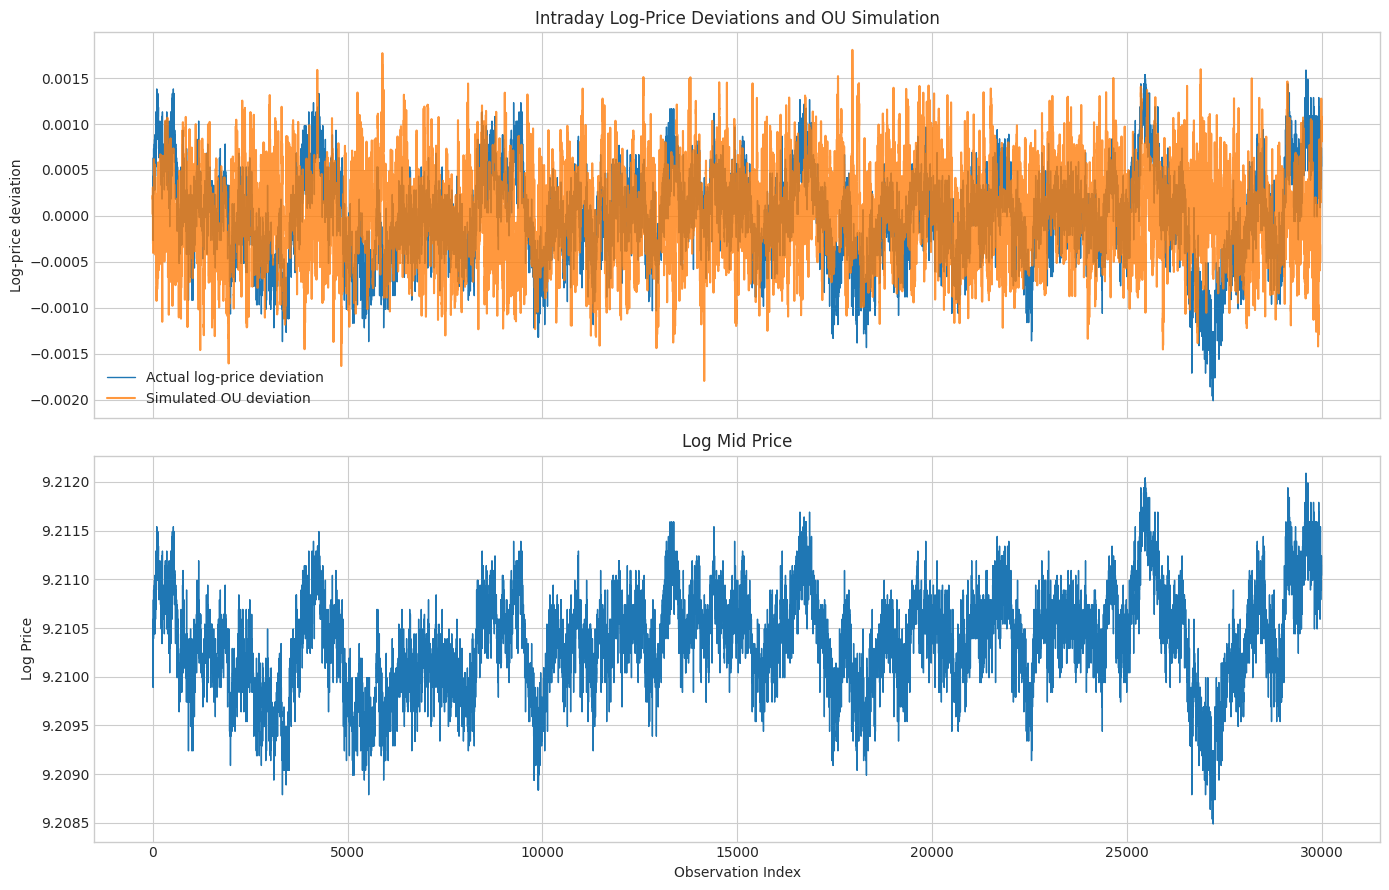

In [20]:
# Fit an OU-style AR(1) model to intraday log-price deviations
prices["log_price"] = np.log(prices["mid_price"])
prices["daily_log_mean"] = prices.groupby("day")["log_price"].transform("mean")
prices["log_price_dev"] = prices["log_price"] - prices["daily_log_mean"]

ou_data = prices[["log_price_dev"]].copy()
ou_data["log_price_dev_prev"] = ou_data["log_price_dev"].shift(1)
mask = ou_data["log_price_dev_prev"].notna()
x = ou_data.loc[mask, "log_price_dev_prev"]
y = ou_data.loc[mask, "log_price_dev"]

phi, intercept = np.polyfit(x, y, 1)
theta = 1.0 - phi
mu = intercept / theta if abs(theta) > 1e-12 else 0.0
resid = y - (phi * x + intercept)
sigma = resid.std(ddof=1)
half_life = np.log(2) / theta if theta > 0 else np.nan
r2 = 1.0 - (resid ** 2).sum() / ((y - y.mean()) ** 2).sum()

print("Ornstein-Uhlenbeck fit to intraday log-price deviations:")
print(f"phi (AR coefficient): {phi:.6f}")
print(f"theta (reversion speed): {theta:.6f}")
print(f"long-term mean mu: {mu:.6f}")
print(f"noise sigma: {sigma:.6e}")
print(f"half-life (ticks): {half_life:.2f}")
print(f"R^2 of AR(1) fit: {r2:.4f}")

# Simulate the fitted OU process for comparison
rng = np.random.default_rng(42)
sim_ou = np.empty(len(ou_data))
sim_ou[0] = ou_data["log_price_dev"].iloc[0]
for i in range(1, len(sim_ou)):
    sim_ou[i] = phi * sim_ou[i - 1] + intercept + sigma * rng.standard_normal()
ou_data["simulated_dev"] = sim_ou
ou_data["fitted_dev"] = np.nan
ou_data.loc[mask, "fitted_dev"] = phi * x + intercept

fig, ax = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
ax[0].plot(prices["event_index"], prices["log_price_dev"], label="Actual log-price deviation", linewidth=1)
ax[0].plot(prices["event_index"], ou_data["simulated_dev"], label="Simulated OU deviation", alpha=0.8)
ax[0].set_title("Intraday Log-Price Deviations and OU Simulation")
ax[0].set_ylabel("Log-price deviation")
ax[0].legend()

ax[1].plot(prices["event_index"], prices["log_price"], color="tab:blue", linewidth=1)
ax[1].set_title("Log Mid Price")
ax[1].set_ylabel("Log Price")
ax[1].set_xlabel("Observation Index")
plt.tight_layout()
plt.show()


In [ ]:
# Strategy: Always buy after a negative log return (hold for one tick)
trade_mask = (
    prices["prev_log_return_sign"].eq(-1) &
    prices["log_return"].notna()
)

prev_mid_price = prices.groupby("day")["mid_price"].shift(1)
entry_ask_price = prices.groupby("day")["ask_price_1"].shift(1)
entry_spread = prices.groupby("day")["spread"].shift(1)
exit_bid_price = prices["bid_price_1"]
exit_spread = prices["spread"]

tradable_trade_mask = (
    trade_mask
    & prev_mid_price.notna()
    & entry_ask_price.notna()
    & exit_bid_price.notna()
    & prev_mid_price.gt(0)
    & entry_ask_price.gt(0)
    & exit_bid_price.gt(0)
)

gross_trade_log_returns = prices.loc[trade_mask, "log_return"]
net_trade_log_returns = np.log(exit_bid_price[tradable_trade_mask] / entry_ask_price[tradable_trade_mask])
round_trip_spread_cost_bps = (
    np.log(entry_ask_price[tradable_trade_mask] / prev_mid_price[tradable_trade_mask])
    + np.log(prices.loc[tradable_trade_mask, "mid_price"] / exit_bid_price[tradable_trade_mask])
) * 10_000

num_trades = int(trade_mask.sum())
tradable_num_trades = int(tradable_trade_mask.sum())
gross_win_rate = (gross_trade_log_returns > 0).mean() * 100 if len(gross_trade_log_returns) else np.nan
net_win_rate = (net_trade_log_returns > 0).mean() * 100 if len(net_trade_log_returns) else np.nan

expected_log_return_per_trade = gross_trade_log_returns.mean()
expected_net_log_return_per_trade = net_trade_log_returns.mean()
expected_total_log_return = num_trades * expected_log_return_per_trade if pd.notna(expected_log_return_per_trade) else np.nan
expected_total_return_pct = (np.exp(expected_total_log_return) - 1) * 100 if pd.notna(expected_total_log_return) else np.nan
expected_total_net_log_return = tradable_num_trades * expected_net_log_return_per_trade if pd.notna(expected_net_log_return_per_trade) else np.nan
expected_total_net_return_pct = (np.exp(expected_total_net_log_return) - 1) * 100 if pd.notna(expected_total_net_log_return) else np.nan

print("Strategy: Always Buy After Negative Log Return")
print(f"Number of signals: {num_trades}")
print(f"Tradable signals with two-sided quotes: {tradable_num_trades}")
print(f"Gross win rate: {gross_win_rate:.2f}%")
print(f"Net win rate after spread: {net_win_rate:.2f}%")
print(f"Average gross log return per trade: {expected_log_return_per_trade:.6f}")
print(f"Average net log return per trade: {expected_net_log_return_per_trade:.6f}")
print(f"Average entry spread: {entry_spread[tradable_trade_mask].mean():.4f}")
print(f"Average exit spread: {exit_spread[tradable_trade_mask].mean():.4f}")
print(f"Average round-trip spread cost: {round_trip_spread_cost_bps.mean():.2f} bps")
print(f"Gross expected total return: {expected_total_return_pct:.2f}%")
print(f"Net expected total return after spread: {expected_total_net_return_pct:.2f}%")

# Compare to buy-and-hold
print("\nComparison to Buy-and-Hold:")
print(f"Buy-and-Hold total return: {total_return_pct:.2f}%")
print(f"Gross strategy vs Buy-and-Hold: {expected_total_return_pct - total_return_pct:.2f} percentage points difference")
print(f"Net strategy vs Buy-and-Hold: {expected_total_net_return_pct - total_return_pct:.2f} percentage points difference")


In [ ]:
# Calculate Kelly Criterion for the spread-adjusted mean reversion strategy
positive_returns = net_trade_log_returns[net_trade_log_returns > 0]
negative_returns = net_trade_log_returns[net_trade_log_returns < 0]

avg_win = positive_returns.mean() if len(positive_returns) else np.nan
avg_loss = negative_returns.mean() if len(negative_returns) else np.nan
avg_loss_abs = abs(avg_loss) if pd.notna(avg_loss) else np.nan
win_prob = len(positive_returns) / tradable_num_trades if tradable_num_trades > 0 else np.nan
loss_prob = len(negative_returns) / tradable_num_trades if tradable_num_trades > 0 else np.nan

if tradable_num_trades > 0 and pd.notna(avg_win) and pd.notna(avg_loss) and avg_loss != 0:
    b = avg_win / abs(avg_loss)
    kelly_fraction = (b * win_prob - loss_prob) / b
else:
    b = np.nan
    kelly_fraction = np.nan

print("Kelly Criterion Calculation (Spread-Adjusted):")
print(f"Average win: {avg_win:.6f}")
print(f"Average loss: {avg_loss_abs:.6f}")
print(f"Win probability: {win_prob:.4f}")
print(f"Loss probability: {loss_prob:.4f}")
print(f"Odds ratio (b): {b:.4f}")
print(f"Kelly fraction: {kelly_fraction:.4f} ({kelly_fraction * 100:.2f}% of capital per trade)")
